In [1]:
import sys
sys.path.append('/machfs/swhite/pyml/pyacal-test')
import pyacal
import os
import warnings
import at
import matplotlib.pyplot as plt
import time
import numpy
plt.rcParams['figure.figsize'] = [20, 10]
from pyacal.experiments.orbrespm import OrbRespm

In [2]:
pyacal.set_facility('esrf')
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    path = '/operation/beamdyn/matlab/optics/sr/theory/'
    ring = at.load_lattice('./betamodel.mat', use='betamodel')
pyacal.set_model('EBS', ring)

In [3]:
orbrespm = OrbRespm(accelerator='EBS', isonline=True)
orbrespm.params.delta_freq = 100   # [Hz]
orbrespm.params.delta_stren_hcm = 5.0e-5  # [rad]
orbrespm.params.delta_stren_vcm = 5.0e-5  # [rad]
orbrespm.params.sofb_nrpoints = 20
print(orbrespm.params)
print(f"Connected? {orbrespm.connected}")

delta_freq               =  1.00e+02  
delta_stren_hcm          =  5.00e-05  
delta_stren_vcm          =  5.00e-05  
sofb_nrpoints            =        20  

Connected? True


In [4]:
orbrespm._run()

Starting measurement at 2024-08-24 19h58m36s

001/064
19h58m36s --> Measuring OrbRespm for CH-SF2-C04-A

002/064
19h58m50s --> Measuring OrbRespm for CH-SF2-C05-A

003/064
19h59m04s --> Measuring OrbRespm for CH-SF2-C06-A

004/064
19h59m17s --> Measuring OrbRespm for CH-SF2-C07-A

005/064
19h59m31s --> Measuring OrbRespm for CH-SF2-C08-A

006/064
19h59m45s --> Measuring OrbRespm for CH-SF2-C09-A

007/064
19h59m58s --> Measuring OrbRespm for CH-SF2-C10-A

008/064
20h00m12s --> Measuring OrbRespm for CH-SF2-C11-A

009/064
20h00m25s --> Measuring OrbRespm for CH-SF2-C12-A

010/064
20h00m39s --> Measuring OrbRespm for CH-SF2-C13-A

011/064
20h00m53s --> Measuring OrbRespm for CH-SF2-C14-A

012/064
20h01m06s --> Measuring OrbRespm for CH-SF2-C15-A

013/064
20h01m20s --> Measuring OrbRespm for CH-SF2-C16-A

014/064
20h01m34s --> Measuring OrbRespm for CH-SF2-C17-A

015/064
20h01m47s --> Measuring OrbRespm for CH-SF2-C18-A

016/064
20h02m01s --> Measuring OrbRespm for CH-SF2-C19-A

017/064
20

dict_keys(['timestamp', 'orbrespm', 'hcm_enbl', 'vcm_enbl', 'rfg_enbl'])
(640, 65)


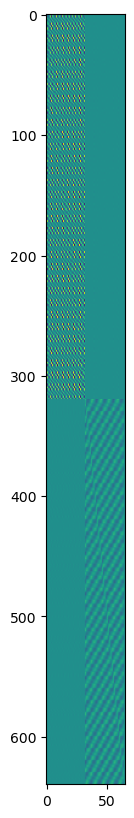

In [5]:
print(orbrespm.data.keys())
orm = orbrespm.data['orbrespm']
print(orm.shape)

plt.imshow(orm)

In [6]:
import pickle
with open('orm_sf2.pkl', 'wb') as f:
    pickle.dump(orbrespm.data, f)